In [4]:
import sys
sys.path.append(r"C:\Users\bayih\PycharmProjects\QuantDevProject\QuantForge\01_pricing_engine")

import numpy as np
import matplotlib.pyplot as plt
from black_scholes import bs_call_price, bs_greeks
from monte_carlo import mc_call_price

# Paramètres de base
S0 = 100
r = 0.05
sigma = 0.2
T = 1.0

print("Imports OK")

Imports OK


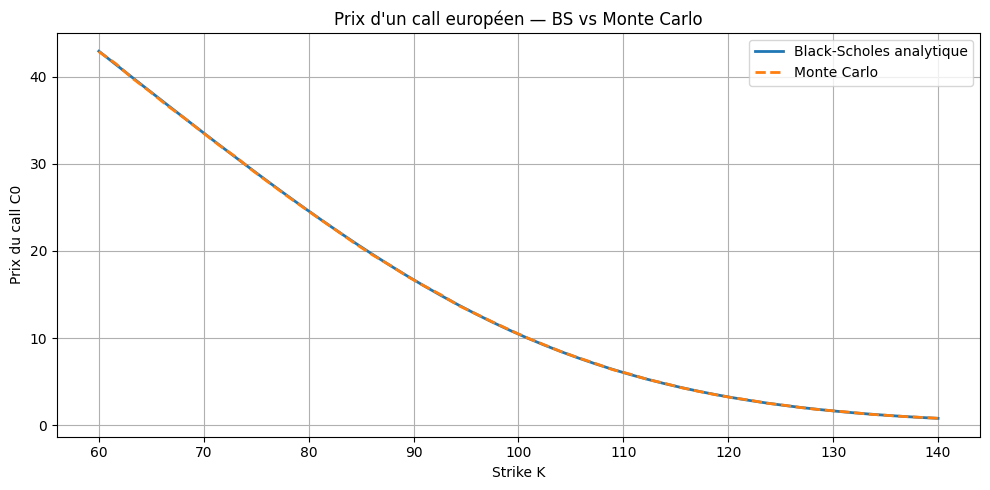

In [5]:
# Graphe 1 — Prix du call en fonction du strike K
strikes = np.linspace(60, 140, 50)

bs_prices = [bs_call_price(S0, K, r, sigma, T) for K in strikes]
mc_prices = [mc_call_price(S0, K, r, sigma, T) for K in strikes]

plt.figure(figsize=(10, 5))
plt.plot(strikes, bs_prices, label="Black-Scholes analytique", linewidth=2)
plt.plot(strikes, mc_prices, label="Monte Carlo", linestyle="--", linewidth=2)
plt.xlabel("Strike K")
plt.ylabel("Prix du call C0")
plt.title("Prix d'un call européen — BS vs Monte Carlo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

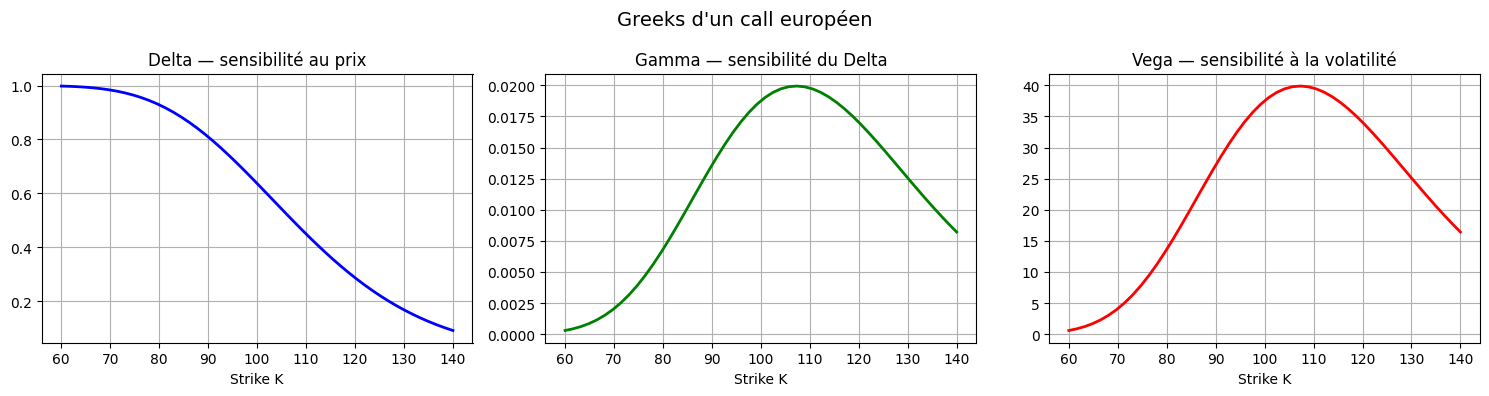

In [6]:
# Graphe 2 — Greeks en fonction du strike K
deltas = []
gammas = []
vegas = []

for K in strikes:
    d, g, v = bs_greeks(S0, K, r, sigma, T)
    deltas.append(d)
    gammas.append(g)
    vegas.append(v)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(strikes, deltas, color="blue", linewidth=2)
axes[0].set_title("Delta — sensibilité au prix")
axes[0].set_xlabel("Strike K")
axes[0].grid(True)

axes[1].plot(strikes, gammas, color="green", linewidth=2)
axes[1].set_title("Gamma — sensibilité du Delta")
axes[1].set_xlabel("Strike K")
axes[1].grid(True)

axes[2].plot(strikes, vegas, color="red", linewidth=2)
axes[2].set_title("Vega — sensibilité à la volatilité")
axes[2].set_xlabel("Strike K")
axes[2].grid(True)

plt.suptitle("Greeks d'un call européen", fontsize=14)
plt.tight_layout()
plt.show()

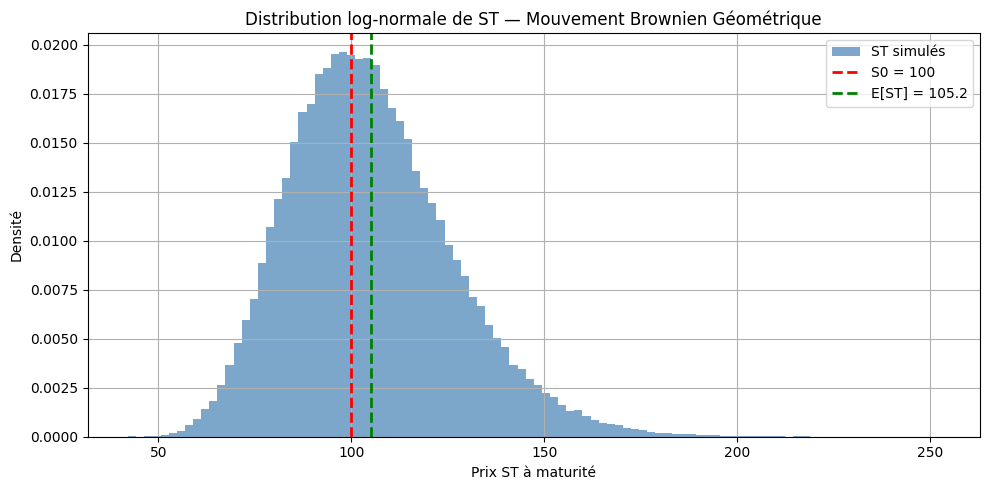

E[ST] = 105.15  (théorique : 105.13)
Médiane ST = 103.10


In [7]:
# Graphe 3 — Distribution des ST simulés
np.random.seed(42)
n_paths = 100000
WT = np.random.standard_normal(n_paths) * np.sqrt(T)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * WT)

plt.figure(figsize=(10, 5))
plt.hist(ST, bins=100, density=True, alpha=0.7, color="steelblue", label="ST simulés")
plt.axvline(S0, color="red", linestyle="--", linewidth=2, label=f"S0 = {S0}")
plt.axvline(np.mean(ST), color="green", linestyle="--", linewidth=2, 
            label=f"E[ST] = {np.mean(ST):.1f}")
plt.xlabel("Prix ST à maturité")
plt.ylabel("Densité")
plt.title("Distribution log-normale de ST — Mouvement Brownien Géométrique")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"E[ST] = {np.mean(ST):.2f}  (théorique : {S0 * np.exp(r*T):.2f})")
print(f"Médiane ST = {np.median(ST):.2f}")